<a href="https://colab.research.google.com/github/riyawakde16-art/Day27/blob/main/Day27.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

Q1. Creating Non-Linear Dataset

In [3]:
X, y = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42)
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df

,Feature1,Feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
...,...,...
495,0.239754,0.985462
496,0.072145,0.184834
497,0.590273,-0.365577
498,1.619465,-0.283658


In [4]:
print("\nFirst 10 Rows:")
df.head(10)


First 10 Rows:


,Feature1,Feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185
5,1.254903,-0.483435
6,1.053851,-0.442690
7,0.031380,1.053012
8,0.620545,0.713096
9,1.787657,-0.142959


In [5]:
print("\nShape of Dataset:")
df.shape


Shape of Dataset:


(500, 2)

Q2. Standard Scaling

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
print("\nFirst 5 rows of Scaled Data:")
scaled_df = pd.DataFrame(
    X_scaled,
    columns=["Feature1", "Feature2"])
print(scaled_df.head())


First 5 rows of Scaled Data:
   Feature1  Feature2
0  0.375125 -1.403679
1  0.226815  1.135628
2  0.595442 -1.493710
3 -0.944918  1.409748
4 -0.243115  1.618062


Q3. KMeans Clustering

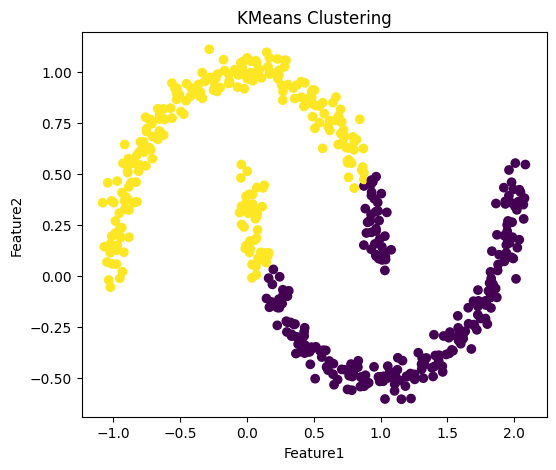

In [7]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(6,5))
plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["kmeans_cluster"],
    cmap="viridis")
plt.title("KMeans Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

Q4. DBSCAN

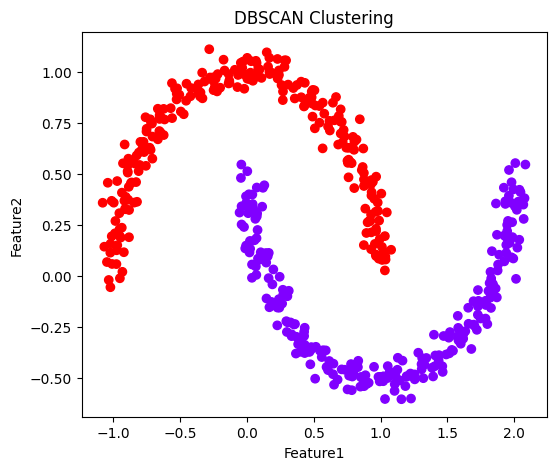

In [8]:
dbscan = DBSCAN(
    eps=0.3,
    min_samples=5)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)
plt.figure(figsize=(6,5))
plt.scatter(
    df["Feature1"],
    df["Feature2"],
    c=df["dbscan_cluster"],
    cmap="rainbow")
plt.title("DBSCAN Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

Q5. Observations

In [9]:
print("""
KMeans:
- Divides data into circular clusters.
- Cannot identify noise.
- Does not work well for moon-shaped data.

DBSCAN:
- Detects non-linear clusters.
- Detects noise points (-1).
- Better suited for moon-shaped dataset.
""")


KMeans:
- Divides data into circular clusters.
- Cannot identify noise.
- Does not work well for moon-shaped data.

DBSCAN:
- Detects non-linear clusters.
- Detects noise points (-1).
- Better suited for moon-shaped dataset.



Q6. DBSCAN Parameter Tuning

In [10]:
results = []
for eps in [0.2, 0.3, 0.4, 0.5]:
    model = DBSCAN(
        eps=eps,
        min_samples=5)
    labels = model.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = list(labels).count(-1)
    results.append([eps, n_clusters, noise])
result_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "Clusters",
        "Noise Points"])
print(result_df)
print("\nBest eps value: 0.3")

   eps  Clusters  Noise Points
0  0.2         2             0
1  0.3         2             0
2  0.4         2             0
3  0.5         2             0

Best eps value: 0.3


Q7. High-Dimensional Dataset

In [11]:
X_blob, y_blob = make_blobs(
    n_samples=500,
    n_features=6,
    centers=4,
    cluster_std=1.5,
    random_state=42)
scaler_blob = StandardScaler()
X_blob_scaled = scaler_blob.fit_transform(X_blob)
print("Scaled Dataset Shape:", X_blob_scaled.shape)

Scaled Dataset Shape: (500, 6)


Q8. PCA

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_blob_scaled)
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"])
pca_df["Cluster"] = y_blob
print("\nFirst 5 Rows:")
print(pca_df.head())
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)


First 5 Rows:
        PC1       PC2  Cluster
0  2.369765  1.259783        1
1 -0.943367 -0.829777        3
2  0.982191 -1.768556        0
3  2.265086  1.190377        1
4  2.142129  0.840804        1

Explained Variance Ratio:
[0.64327878 0.21039738]


Q9. PCA Plot

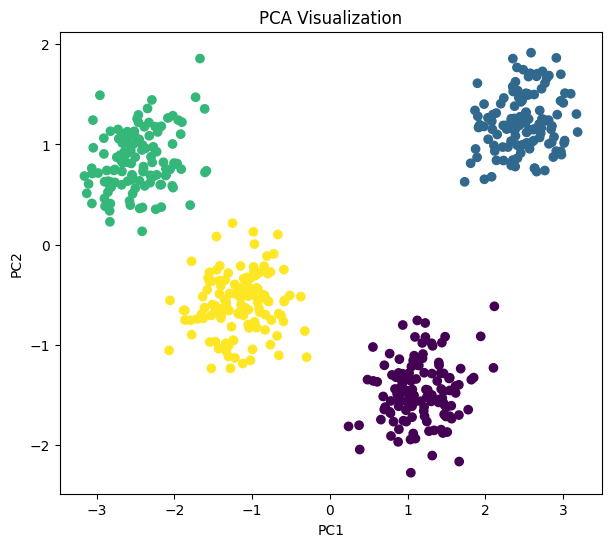


Observation:
The explained variance ratio indicates how much information is
retained after reducing the dataset to two principal components.
Higher values mean less information is lost.



In [13]:
plt.figure(figsize=(7,6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis")
plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("""
Observation:
The explained variance ratio indicates how much information is
retained after reducing the dataset to two principal components.
Higher values mean less information is lost.
""")

Q10. Mini Project

First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Data Scaled Successfully!

First 5 Rows with DBSCAN Cluster:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0

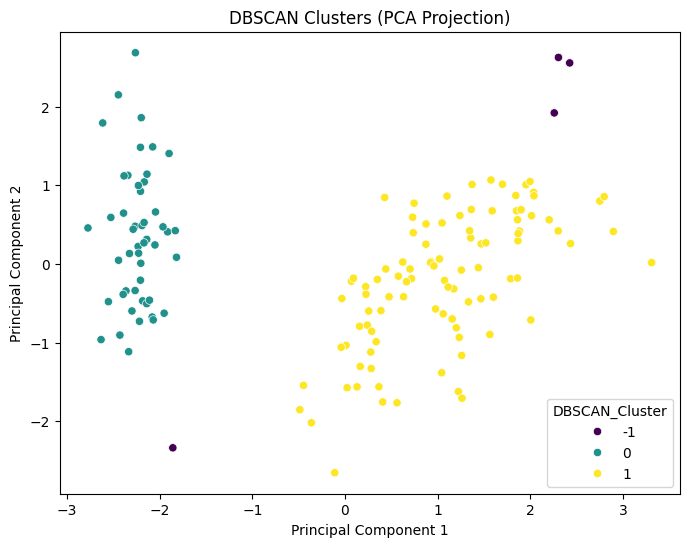


Explained Variance Ratio:
[0.72962445 0.22850762]


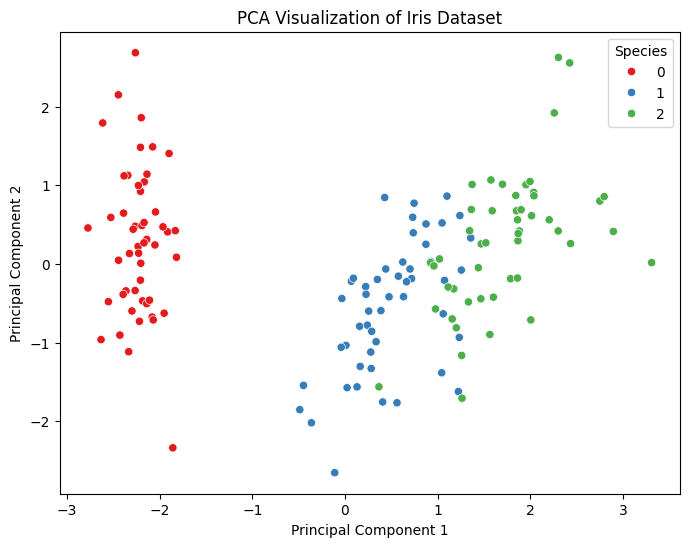


Observation:
1. PCA reduced the dataset from 4 dimensions to 2 dimensions.
2. The explained variance ratio shows how much information is retained.
3. DBSCAN groups similar data points and can identify noise points.
4. The PCA plot helps visualize the clusters in two dimensions.


In [15]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Iris Dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print("First 5 Rows:")
print(df.head())

# Scale the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print("\nData Scaled Successfully!")

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN Labels
df["DBSCAN_Cluster"] = db_labels

print("\nFirst 5 Rows with DBSCAN Cluster:")
print(df.head())

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Add DBSCAN Labels
pca_df["DBSCAN_Cluster"] = db_labels

# Scatter Plot using DBSCAN Labels
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="DBSCAN_Cluster",
    palette="viridis")
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Explained Variance Ratio
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# Add Original Species Labels
pca_df["Species"] = iris.target

# PCA Visualization with Original Species
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Species",
    palette="Set1")
plt.title("PCA Visualization of Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Observation
print("\nObservation:")
print("1. PCA reduced the dataset from 4 dimensions to 2 dimensions.")
print("2. The explained variance ratio shows how much information is retained.")
print("3. DBSCAN groups similar data points and can identify noise points.")
print("4. The PCA plot helps visualize the clusters in two dimensions.")